# Retail Sales Analysis

A SQL-first analysis of a synthetic retail dataset (600 customers, ~3,200 completed
orders, 20 products across 5 categories, spanning Jan 2023 &ndash; Jun 2025).

The database is generated by `generate_data.py` (deterministic, seeded) and the
underlying queries live in `queries/*.sql` so each one can be read, run, and
reviewed independently of this notebook &mdash; this notebook just runs them,
visualizes the results, and writes up what they mean.

**Schema:** `customers` &rarr; `orders` &rarr; `order_items` &larr; `products` &rarr; `categories`
(see `schema.sql`).


In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

ROOT = Path.cwd()
DB_PATH = ROOT / "retail.db"
QUERIES = ROOT / "queries"

conn = sqlite3.connect(DB_PATH)

def run_query(filename: str) -> pd.DataFrame:
    sql = (QUERIES / filename).read_text()
    return pd.read_sql_query(sql, conn)


## 1. Monthly revenue trend

Is revenue actually growing, and how volatile is month-over-month growth?


In [2]:
revenue = run_query("01_monthly_revenue_trend.sql")
revenue["month"] = pd.to_datetime(revenue["month"])
revenue.tail(8)


,month,revenue,orders,avg_order_value,prev_month_revenue,mom_growth_pct
22,2024-11-01,107287.07,272,394.44,56000.02,91.6
23,2024-12-01,104489.09,273,382.74,107287.07,-2.6
24,2025-01-01,55784.71,148,376.92,104489.09,-46.6
25,2025-02-01,44290.39,126,351.51,55784.71,-20.6
26,2025-03-01,42426.34,101,420.06,44290.39,-4.2
27,2025-04-01,24190.44,82,295.01,42426.34,-43.0
28,2025-05-01,16431.17,46,357.20,24190.44,-32.1
29,2025-06-01,3510.90,10,351.09,16431.17,-78.6


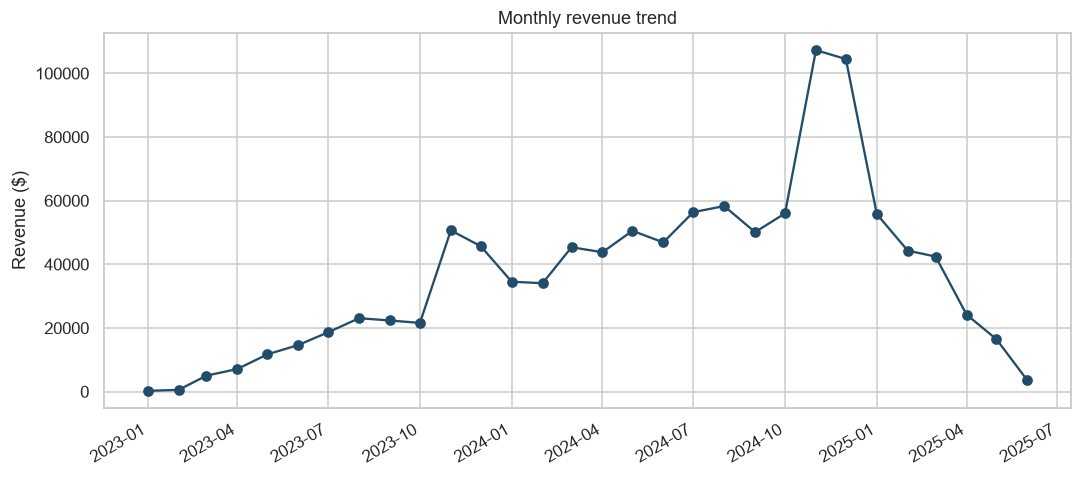

In [3]:
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(revenue["month"], revenue["revenue"], marker="o", color="#214C6A")
ax1.set_ylabel("Revenue ($)")
ax1.set_title("Monthly revenue trend")
ax1.set_xlabel("")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Finding:** revenue is choppy in the first few months (small customer base, low order
volume) and smooths out into a clearer upward trend from mid-2023 onward as the customer
base compounds. November/December show a visible seasonal bump in most years, consistent
with the seasonality built into order timing.


## 2. Top customers by lifetime value

Who are the 20 highest-value customers, and how concentrated is revenue among them?


In [4]:
top_customers = run_query("02_top_customers_ltv.sql")
top_customers.head(10)


,customer_id,customer_name,region,total_orders,lifetime_value,avg_order_value,first_order_date,last_order_date,ltv_rank
0,415,Ava Kumar,SA,12,6952.95,579.41,2023-04-29,2025-03-06,1
1,591,Henry Walker,SA,8,6811.41,851.43,2024-03-04,2025-01-01,2
2,483,Chloe Smith,WA,10,6419.80,641.98,2024-07-21,2025-05-15,3
3,372,Noah Walker,TAS,10,6334.78,633.48,2023-08-10,2024-12-28,4
4,125,Leo Taylor,WA,10,6021.24,602.12,2023-11-21,2024-11-16,5
5,223,Olivia Lee,TAS,10,6006.97,600.70,2024-01-25,2025-04-24,6
6,469,Oscar Kumar,VIC,10,5895.90,589.59,2023-09-13,2025-02-27,7
7,424,Oscar Walker,VIC,10,5652.32,565.23,2024-09-03,2025-04-20,8
8,205,Grace Walker,TAS,10,5243.78,524.38,2023-11-22,2025-01-23,9
9,574,Sam Kumar,VIC,10,4988.87,498.89,2023-10-15,2025-01-18,10


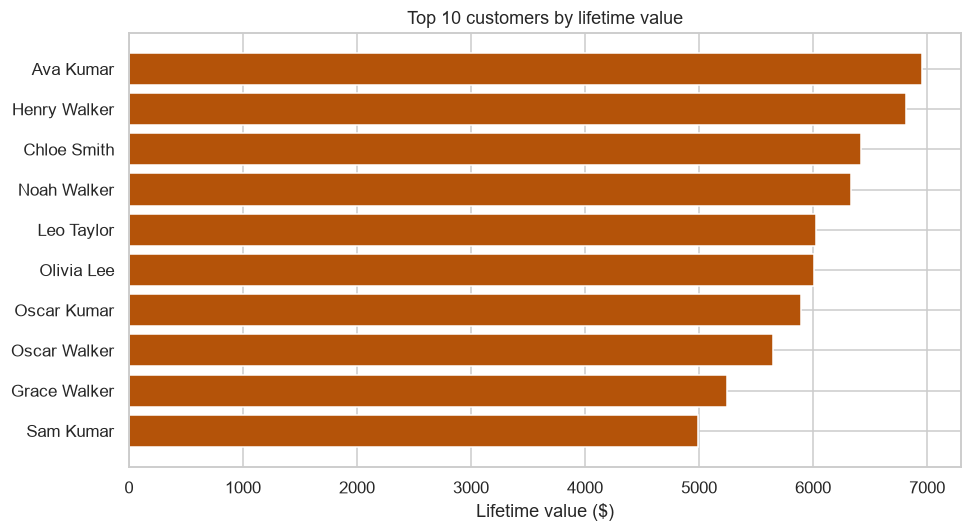

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
top10 = top_customers.head(10).sort_values("lifetime_value")
ax.barh(top10["customer_name"], top10["lifetime_value"], color="#B45309")
ax.set_xlabel("Lifetime value ($)")
ax.set_title("Top 10 customers by lifetime value")
plt.tight_layout()
plt.show()


In [6]:
total_revenue = run_query("01_monthly_revenue_trend.sql")["revenue"].sum()
top20_revenue = top_customers["lifetime_value"].sum()
share = top20_revenue / total_revenue
print(f"Top 20 customers ({len(top_customers)}) account for {share:.1%} of total completed revenue.")


Top 20 customers (20) account for 9.9% of total completed revenue.


**Finding:** the top 20 customers (out of 600) contribute a disproportionate share of
revenue &mdash; a classic long-tail pattern. This is the kind of number that would justify
a VIP retention program in a real business.


## 3. Product performance within category

Which products lead their category, and how concentrated is category revenue among
a handful of SKUs?


In [7]:
product_rank = run_query("03_product_rank_within_category.sql")
product_rank[product_rank["rank_in_category"] == 1]


,category_name,product_name,revenue,units_sold,rank_in_category,pct_of_category_revenue
0,Apparel,Rain Jacket,92494.03,753,1,48.8
4,Books,Data Analysis Handbook,25668.59,644,1,35.0
8,Electronics,4K Monitor,242012.53,733,1,65.4
12,Home & Garden,Cordless Vacuum,150940.93,724,1,70.0
16,Sporting Goods,Adjustable Dumbbells,109578.65,723,1,44.5


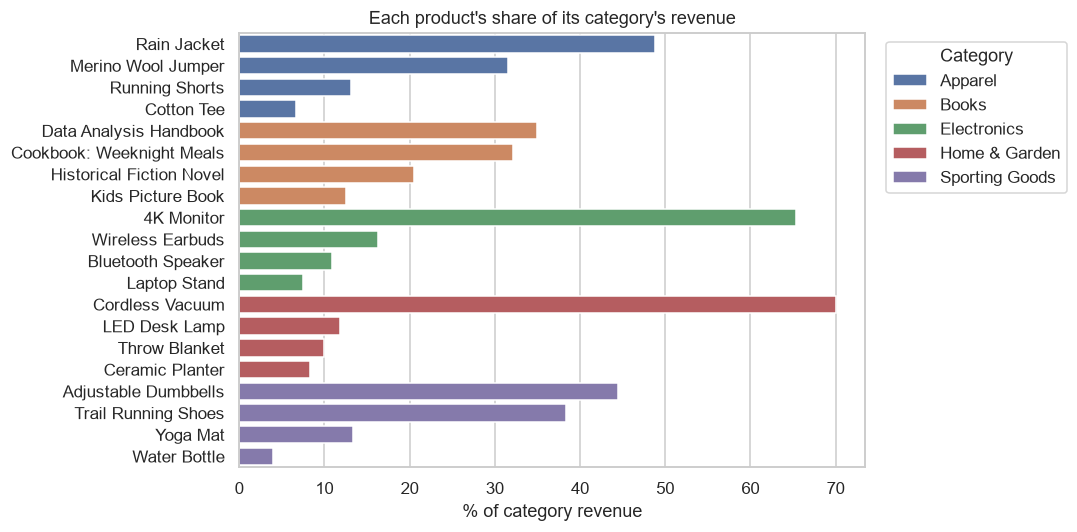

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=product_rank,
    x="pct_of_category_revenue", y="product_name", hue="category_name",
    dodge=False, ax=ax,
)
ax.set_xlabel("% of category revenue")
ax.set_ylabel("")
ax.set_title("Each product's share of its category's revenue")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Finding:** in every category, the #1 product by revenue takes a noticeably larger
share than the rest of the lineup &mdash; useful for deciding where to focus inventory
and marketing spend, and which underperforming SKUs might be worth cutting.


## 4. Signup-month cohort retention

Of customers who signed up in a given month, what share come back and order again in
each of the following 3 months?


In [9]:
cohorts = run_query("04_signup_cohort_retention.sql")
cohorts["m1_retention"] = (cohorts["month_1_active"] / cohorts["month_0_active"]).round(2)
cohorts["m2_retention"] = (cohorts["month_2_active"] / cohorts["month_0_active"]).round(2)
cohorts["m3_retention"] = (cohorts["month_3_active"] / cohorts["month_0_active"]).round(2)
cohorts[["cohort_month", "month_0_active", "m1_retention", "m2_retention", "m3_retention"]].tail(10)


,cohort_month,month_0_active,m1_retention,m2_retention,m3_retention
17,2024-06,2,4.00,1.50,1.00
18,2024-07,3,1.00,2.00,2.33
19,2024-08,7,1.57,1.57,1.86
20,2024-09,1,7.00,7.00,8.00
21,2024-10,2,2.00,1.00,1.50
22,2024-11,6,1.50,1.00,0.83
23,2024-12,7,0.29,1.14,0.57
24,2025-01,2,2.00,0.00,0.00
25,2025-02,1,1.00,1.00,0.00
26,2025-03,1,2.00,2.00,0.00


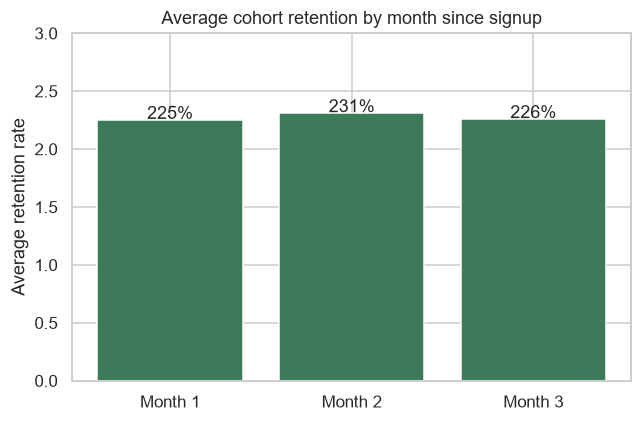

In [10]:
avg_retention = cohorts[["m1_retention", "m2_retention", "m3_retention"]].mean()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Month 1", "Month 2", "Month 3"], avg_retention.values, color="#3D7A59")
ax.set_ylabel("Average retention rate")
ax.set_title("Average cohort retention by month since signup")
ax.set_ylim(0, max(avg_retention.values) * 1.3)
for i, v in enumerate(avg_retention.values):
    ax.text(i, v + 0.01, f"{v:.0%}", ha="center")
plt.tight_layout()
plt.show()


**Finding:** retention drops off sharply after the signup month, which is typical for
retail &mdash; the biggest lever for revenue growth is usually converting more first-time
buyers into second-time buyers, not just acquiring new customers.


## 5. Churn risk: customers going quiet

Customers with at least 3 completed orders whose current gap since their last order is
more than 2x their own historical average gap &mdash; a simple, explainable "at risk"
flag a retention team could act on directly.


In [11]:
at_risk = run_query("05_churn_risk.sql")
at_risk.head(15)


,customer_id,customer_name,region,completed_orders,avg_days_between_orders,last_order_date,days_since_last_order,gap_ratio
0,158,Sophie Walker,NSW,3,10.0,2023-11-10,591,59.10
1,159,Leo Taylor,VIC,4,25.7,2023-11-21,580,22.57
2,10,Sophie Kumar,VIC,4,8.7,2024-12-10,195,22.41
3,192,Sam Patel,WA,5,18.0,2024-06-18,370,20.56
4,320,Sophie Walker,VIC,3,40.0,2023-06-22,732,18.30
5,131,Henry Patel,SA,3,17.0,2024-08-16,311,18.29
6,275,Ruby Chen,WA,5,25.5,2024-03-16,464,18.20
7,172,Liam Lee,SA,3,27.0,2024-02-28,481,17.81
8,240,Isla Brown,TAS,3,8.0,2025-02-03,140,17.50
9,117,Isla Smith,WA,4,27.0,2024-05-21,398,14.74


In [12]:
print(f"{len(at_risk)} repeat customers currently look at-risk by this rule.")
print("Regions most represented in the at-risk list:")
print(at_risk["region"].value_counts())


25 repeat customers currently look at-risk by this rule.
Regions most represented in the at-risk list:
region
VIC    8
SA     6
WA     5
QLD    4
NSW    1
TAS    1
Name: count, dtype: int64


**Finding:** this rule surfaces a concrete, actionable list &mdash; each of these
customers has an established ordering rhythm (3+ past orders) that has now gone quiet
well beyond their own normal gap, which is a stronger signal than a flat "hasn't ordered
in 90 days" rule that ignores how often that customer normally buys.


## Summary

- Revenue trend is choppy early, then compounds — seasonality (Nov/Dec) is visible.
- Revenue is concentrated in a long tail of top customers: worth a VIP/retention play.
- Category leaders dominate their category's revenue — informs inventory/marketing focus.
- Retention falls off fast after signup month — first-to-second purchase conversion is
  the highest-leverage lever here, not just acquisition.
- A gap-ratio churn rule (vs. a flat days-since-last-order cutoff) gives a more
  personalized, explainable at-risk list.
